In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import warnings
import mlflow
warnings.filterwarnings('ignore')

sys.path.append('../scripts')
from data_pipeline import load_and_prepare_data, load_single_channel
from feature_engineering import build_model_input
from algorithms import gpr
import plots, evaluate

# Set MLflow tracking to project root (not notebooks folder)
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("GPR_Battery_Degradation")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Experiment: artifact_location='file:///Users/nithin.jakrebet/Desktop/eis-ml/notebooks/../mlruns/647135219833768094', creation_time=1762199017930, experiment_id='647135219833768094', last_update_time=1762199017930, lifecycle_stage='active', name='GPR_Battery_Degradation', tags={}>

In [3]:
# Fix the data path - using Li_highC_25C which exists
X_train_loso, X_test_loso, y_train_loso, y_test_loso = load_and_prepare_data(data_folder="../data/Li_highC_25C")

X_train: (1932, 66), y_train: (1932,)
X_test: (266, 66), y_test: (266,)
Train capacity range: 0.0 - 1.0 mAh
Test capacity range: 0.7 - 1.0 mAh


# Faster Model training

In [4]:
cap_model = gpr.train_capacity_gpr_fast(
    X_train_loso, y_train_loso,
    subset_size=300,
    top_k_freqs=None  
)

In [ ]:
# Start MLflow run for GPR experiment
if mlflow.active_run():
    mlflow.end_run()

mlflow.start_run(run_name="GPR_LOSO_04-03-24")

# Log parameters
mlflow.log_param("model_type", "Gaussian Process Regression")
mlflow.log_param("split_method", "LOSO")
mlflow.log_param("data_folder", "04-03-24")
mlflow.log_param("subset_size", 300)
mlflow.log_param("train_size", X_train_loso.shape[0])
mlflow.log_param("test_size", X_test_loso.shape[0])
mlflow.log_param("n_features", X_train_loso.shape[1])

In [5]:
y_pred_mean, y_pred_std = gpr.predict_fast(cap_model, X_test_loso)

RMSE: 0.0154
R²: 0.9357
MSE: 0.0002
MAE: 0.0128
  Mean Prediction Uncertainty: 0.0091


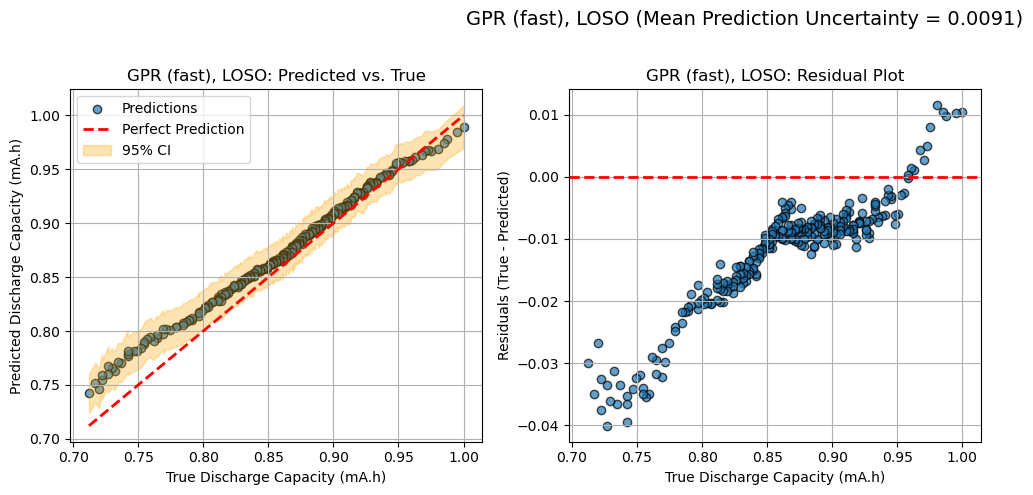

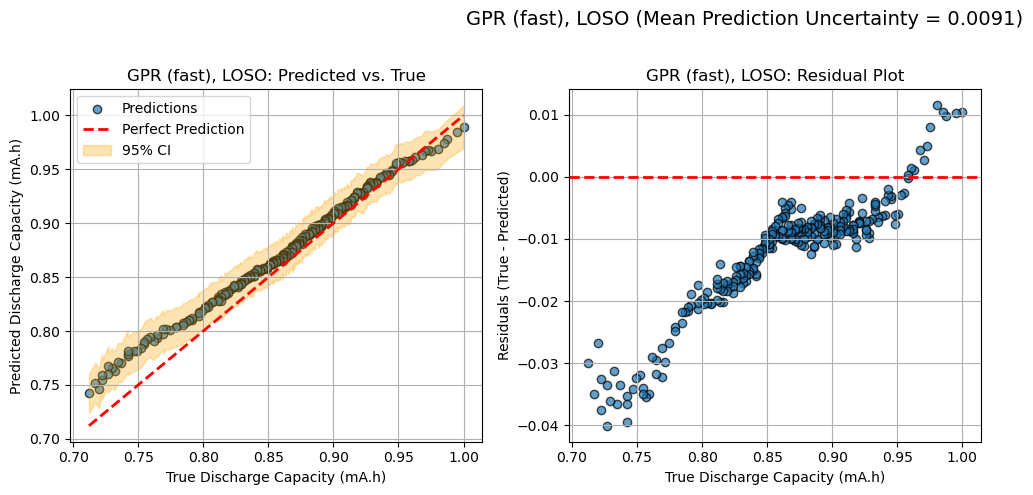

In [6]:
rmse, r2, mse, mae = evaluate.evaluate_model(y_test_loso, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
plots.model_predictions(y_test_loso, y_pred_mean, y_pred_std, title_prefix="GPR (fast), LOSO")

# Binning split

In [8]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = load_and_prepare_data(data_folder="../data/Li_highC_25C",method='bin_and_split')

X_train: (1727, 66), y_train: (1727,)
X_test: (471, 66), y_test: (471,)
Train capacity range: 0.0 - 1.0 mAh
Test capacity range: 0.0 - 1.0 mAh


In [12]:
cap_model = gpr.train_capacity_gpr_fast(
    X_train_bin, y_train_bin,
    top_k_freqs=None  
)

In [10]:
y_pred_mean, y_pred_std = gpr.predict_fast(cap_model, X_test_bin)

RMSE: 0.0478
R²: 0.9730
MSE: 0.0023
MAE: 0.0430
  Mean Prediction Uncertainty: 0.0087


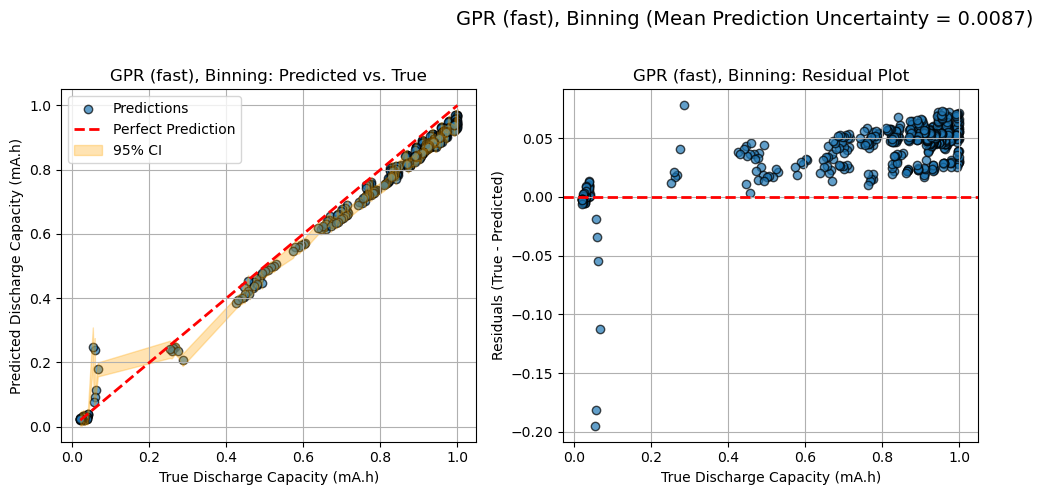

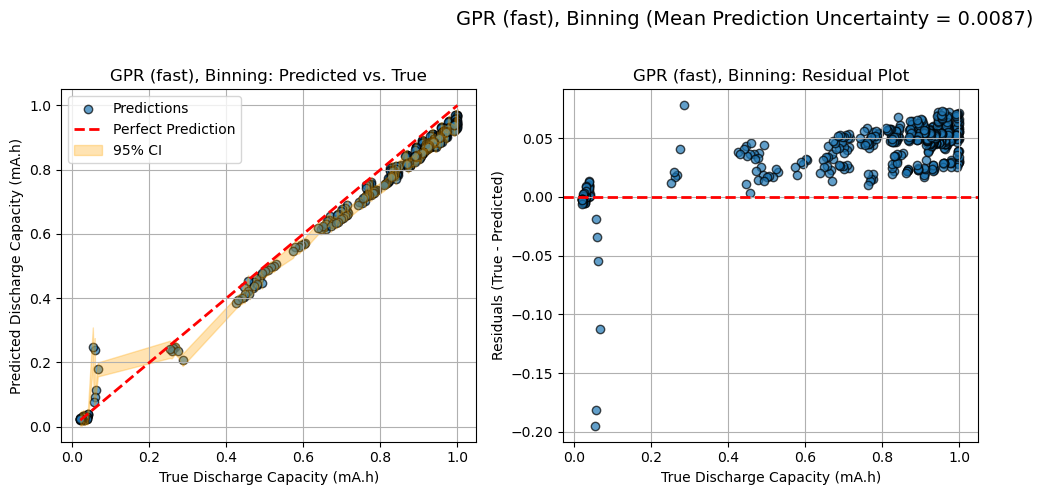

In [13]:
rmse, r2, mse, mae = evaluate.evaluate_model(y_test_bin, y_pred_mean)
print(f"RMSE: {rmse:.4f}\nR²: {r2:.4f}\nMSE: {mse:.4f}\nMAE: {mae:.4f}")
plots.model_predictions(y_test_bin, y_pred_mean, y_pred_std, title_prefix="GPR (fast), Binning")

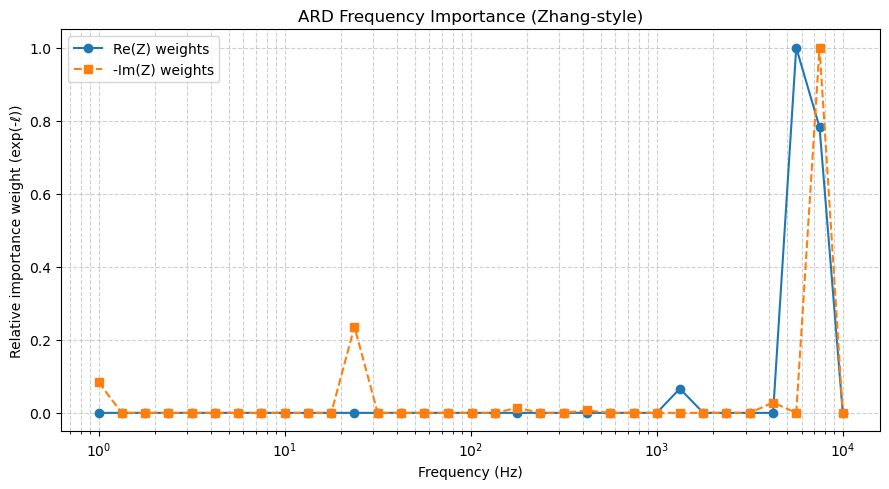

Top 5 most relevant frequencies (Hz): [7.50e+03 5.62e+03 2.37e+01 9.99e-01 1.33e+03]
Corresponding weights: [0.89099926 0.5        0.11793708 0.04177674 0.03312416]


In [14]:
w = gpr.ard_frequency_weights(cap_model)       # shape (66,)
plots.gpr_weights(w)

In [15]:
# Split into Re/Im and aggregate per frequency
n_freq = w.size // 2
w_re, w_im = w[:n_freq], w[n_freq:]
w_mean = (w_re + w_im) / 2

# Top frequencies
top = np.argsort(w_mean)[::-1][:10]
print("Top-10 freqs (index):", top)
print("Weights:", w_mean[top])

Top-10 freqs (index): [31 30 11  0 25 29 18 21  6 22]
Weights: [8.90999263e-01 5.00000000e-01 1.17937078e-01 4.17767414e-02
 3.31241649e-02 1.41562303e-02 6.87624122e-03 3.32809448e-03
 6.43459402e-07 6.38741233e-29]


# Fast Loso with Determined weights

In [18]:
def loso(train_channels, test_channels):
    train_channels_data = {}
    test_channels_data = {}
    for channel in train_channels: train_channels_data[channel] = load_single_channel("../data/Li_highC_25C", channel)    
    for channel in test_channels: test_channels_data[channel] = load_single_channel("../data/Li_highC_25C", channel)
    train_dfs = list(train_channels_data.values())
    test_dfs = list(test_channels_data.values())

    return pd.concat(train_dfs, ignore_index=True), pd.concat(test_dfs, ignore_index=True)


In [19]:
CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']
results = []

for test_cell in CHANNELS:
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])

    X_train, y_train = build_model_input(df_train)
    X_test,  y_test  = build_model_input(df_test)

    model = gpr.train_capacity_gpr_fast(X_train, y_train, subset_size=500)
    y_pred, y_std = gpr.predict_fast(model, X_test)

    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    results.append((test_cell, rmse, mae, r2))


In [20]:
results

[('A1',
  np.float64(0.033062351613564966),
  0.021217149247911044,
  0.9048587632489561),
 ('A2',
  np.float64(0.040104572245541405),
  0.03672153478860385,
  0.905581508914052),
 ('A3',
  np.float64(0.04797986724158641),
  0.03882827872464794,
  0.695861813829624),
 ('A4',
  np.float64(0.11418995370636845),
  0.06278585804177103,
  0.6694037467983323),
 ('A5',
  np.float64(0.08772858412587867),
  0.06927034597354102,
  0.9466977218471702),
 ('A6',
  np.float64(0.009389934271421199),
  0.00921094673142599,
  0.8849127667035696),
 ('A7',
  np.float64(0.12577429178632976),
  0.09219280411474588,
  0.8862471421499831),
 ('A8',
  np.float64(0.008492070866672584),
  0.006267394977496405,
  0.9804126803929528)]

# Efficient Single-Pass LOSO Experiment
Run once, save all models, extract both performance metrics and ARD weights

In [28]:
import joblib
from pathlib import Path

CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']

results = []
models = {}  # Store all trained models
W_re, W_im = [], []  # ARD weights

# Create model save directory
model_dir = Path("../models/gpr_loso")
model_dir.mkdir(parents=True, exist_ok=True)


for i, test_cell in enumerate(CHANNELS):
    print(f"Fold {i+1}/8: Training on all cells except {test_cell}")
    
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])
    
    X_train, y_train = build_model_input(df_train)
    X_test, y_test = build_model_input(df_test)
    
    model = gpr.train_capacity_gpr_fast(X_train, y_train)
    
    model_path = model_dir / f"gpr_model_{test_cell}_holdout.pkl"
    joblib.dump(model, model_path)
    models[test_cell] = model
    print(f"Saved model to {model_path}")
    
    y_pred, y_std = gpr.predict_fast(model, X_test)
    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    results.append((test_cell, rmse, mae, r2))
    print(f"R²: {r2:.3f}, RMSE: {rmse:.3f}")
    
    w = gpr.ard_frequency_weights(model)
    n_freq = w.size // 2
    w_re = w[:n_freq]
    w_im = w[n_freq:]
    
    W_re.append(w_re)
    W_im.append(w_im)

Fold 1/8: Training on all cells except A1


Saved model to ../models/gpr_loso/gpr_model_A1_holdout.pkl
R²: 0.932, RMSE: 0.028
Fold 2/8: Training on all cells except A2
Saved model to ../models/gpr_loso/gpr_model_A2_holdout.pkl
R²: 0.948, RMSE: 0.030
Fold 3/8: Training on all cells except A3
Saved model to ../models/gpr_loso/gpr_model_A2_holdout.pkl
R²: 0.948, RMSE: 0.030
Fold 3/8: Training on all cells except A3
Saved model to ../models/gpr_loso/gpr_model_A3_holdout.pkl
R²: 0.697, RMSE: 0.048
Fold 4/8: Training on all cells except A4
Saved model to ../models/gpr_loso/gpr_model_A3_holdout.pkl
R²: 0.697, RMSE: 0.048
Fold 4/8: Training on all cells except A4
Saved model to ../models/gpr_loso/gpr_model_A4_holdout.pkl
R²: 0.926, RMSE: 0.054
Fold 5/8: Training on all cells except A5
Saved model to ../models/gpr_loso/gpr_model_A4_holdout.pkl
R²: 0.926, RMSE: 0.054
Fold 5/8: Training on all cells except A5
Saved model to ../models/gpr_loso/gpr_model_A5_holdout.pkl
R²: 0.929, RMSE: 0.101
Fold 6/8: Training on all cells except A6
Saved mo

In [29]:
# Save performance results
df = pd.DataFrame(results, columns=["cell", "rmse", "mae", "r2"]).sort_values("cell")
summary = pd.DataFrame({
    "cell": ["_mean_"],
    "rmse": [df["rmse"].mean()],
    "mae": [df["mae"].mean()],
    "r2": [df["r2"].mean()],
})
df_out = pd.concat([df, summary], ignore_index=True)

# Save results
save_dir = Path("../results/gpr")
save_dir.mkdir(parents=True, exist_ok=True)

csv_path = save_dir / "gpr_8_fold_cv_results.csv"
json_path = save_dir / "gpr_8_fold_cv_results.json"

df_out.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    import json
    json.dump(df.to_dict(orient="records"), f, indent=2)

print(f"Results saved to:\n  • {csv_path}\n  • {json_path}")
print("\nPerformance Summary:")
print(df_out)

Results saved to:
  • ../results/gpr/gpr_8_fold_cv_results.csv
  • ../results/gpr/gpr_8_fold_cv_results.json

Performance Summary:
     cell      rmse       mae        r2
0      A1  0.027970  0.021880  0.931910
1      A2  0.029851  0.025457  0.947689
2      A3  0.047858  0.039903  0.697405
3      A4  0.053987  0.045582  0.926104
4      A5  0.101440  0.088146  0.928734
5      A6  0.006256  0.005215  0.948912
6      A7  0.106512  0.071395  0.918422
7      A8  0.015381  0.012830  0.935743
8  _mean_  0.048657  0.038801  0.904365


# Plot weights

In [30]:
# Process and save ARD weights (same as before)
W_re = np.vstack(W_re)
W_im = np.vstack(W_im)

re_mean, re_std = W_re.mean(axis=0), W_re.std(axis=0)
im_mean, im_std = W_im.mean(axis=0), W_im.std(axis=0)
avg_mean = (re_mean + im_mean) / 2.0
avg_std = np.sqrt((re_std**2 + im_std**2) / 2.0)

freqs_hz = [
    0.999, 1.33, 1.78, 2.37, 3.16, 4.22, 5.62, 7.5, 
    10.0, 13.3, 17.8, 23.7, 31.6, 42.2, 56.2, 75.0, 
    102.0, 135.0, 178.0, 237.0, 316.0, 422.0, 564.0, 750.0, 
    1000.0, 1330.0, 1780.0, 2370.0, 3160.0, 4220.0, 5620.0, 7500.0, 
    10000.0
]

# Save ARD weights
ard_df = pd.DataFrame({
    "freq_hz": freqs_hz,
    "w_re_mean": re_mean, "w_re_std": re_std,
    "w_im_mean": im_mean, "w_im_std": im_std,
    "w_avg_mean": avg_mean, "w_avg_std": avg_std,
})
ard_csv_path = save_dir / "ard_weights_across_folds.csv"
ard_df.to_csv(ard_csv_path, index=False)

print(f"\nARD weights saved to: {ard_csv_path}")
print(f"All 8 models saved to: {model_dir}")




ARD weights saved to: ../results/gpr/ard_weights_across_folds.csv
All 8 models saved to: ../models/gpr_loso


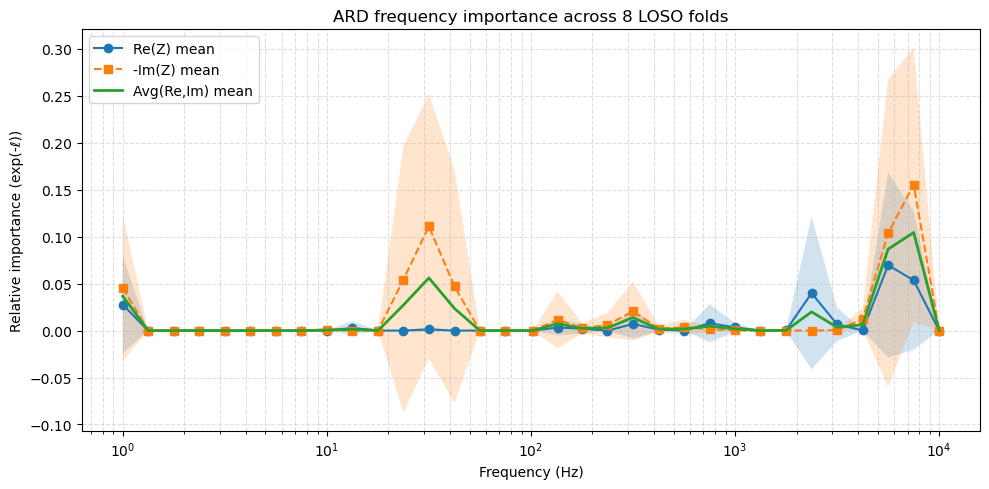

Saved ARD summary to:
- ../results/gpr/gpr_8_fold_cv_results.csv
- ../results/gpr/ard_weights_across_folds.png


<Figure size 640x480 with 0 Axes>

In [32]:
import os

plt = plots.ard_summary(
    freqs_hz, re_mean, re_std, im_mean, im_std, avg_mean
)

png_path = os.path.join(save_dir, "ard_weights_across_folds.png")

plt.savefig(png_path, dpi=180)

print(f"Saved ARD summary to:\n- {csv_path}\n- {png_path}")

# Cross fold LOSO with highest frequencies

In [34]:
CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']
results = []
freqs = [0.999,31.600,2370.000,5620.000,7500.000]

for test_cell in CHANNELS:
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])

    X_train, y_train = build_model_input(df_train, freqs=freqs)
    X_test,  y_test  = build_model_input(df_test, freqs=freqs)

    model = gpr.train_capacity_gpr_fast(X_train, y_train, subset_size=500)
    y_pred, y_std = gpr.predict_fast(model, X_test)

    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    results.append((test_cell, rmse, mae, r2))


In [35]:
import os, json

df = pd.DataFrame(results, columns=["cell", "rmse", "mae", "r2"]).sort_values("cell")

summary = pd.DataFrame({
    "cell": ["_mean_"],
    "rmse": [df["rmse"].mean()],
    "mae":  [df["mae"].mean()],
    "r2":   [df["r2"].mean()],
})
df_out = pd.concat([df, summary], ignore_index=True)

save_dir = os.path.join("../results", "gpr")
os.makedirs(save_dir, exist_ok=True)

csv_path  = os.path.join(save_dir, "gpr-select-freqs_8_fold_cv_results.csv")
json_path = os.path.join(save_dir, "gpr-select-freqs_8_fold_cv_results.json")

df_out.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(df.to_dict(orient="records"), f, indent=2)

print(f"Results saved to:\n  • {csv_path}\n  • {json_path}")
print("\n Fold-wise summary:\n", df_out)


Results saved to:
  • ../results/gpr/gpr-select-freqs_8_fold_cv_results.csv
  • ../results/gpr/gpr-select-freqs_8_fold_cv_results.json

 Fold-wise summary:
      cell      rmse       mae        r2
0      A1  0.020984  0.016401  0.961674
1      A2  0.057464  0.053222  0.806151
2      A3  0.054901  0.044138  0.601784
3      A4  0.132994  0.074059  0.551561
4      A5  0.098843  0.075201  0.932337
5      A6  0.008311  0.007821  0.909832
6      A7  0.116153  0.080932  0.902986
7      A8  0.028085  0.026784  0.785769
8  _mean_  0.064717  0.047320  0.806512


Saved figure to ../results/gpr/gpr_8fold_r2_comparison.png


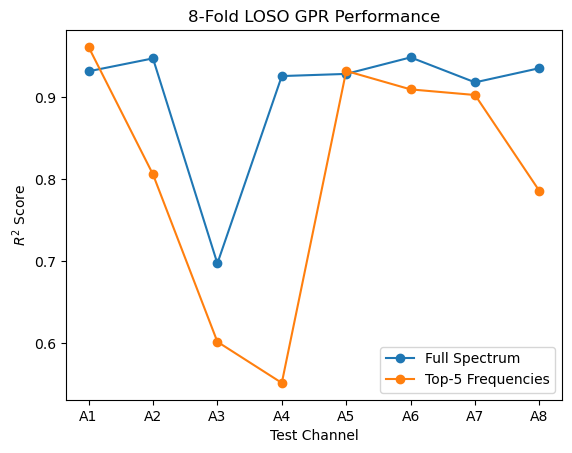

In [36]:
from pathlib import Path

# === Paths ===
results_dir = Path("../results/gpr")
full_file = results_dir / "gpr_8_fold_cv_results.csv"
top_file  = results_dir / "gpr-select-freqs_8_fold_cv_results.csv"

# === Load
df_full = pd.read_csv(full_file)
df_top  = pd.read_csv(top_file)

# Normalize column name: use 'channel'
name_col = "channel" if "channel" in df_full.columns else "cell"
df_full = df_full.rename(columns={name_col: "channel"})
name_col = "channel" if "channel" in df_top.columns else "cell"
df_top  = df_top.rename(columns={name_col: "channel"})

# Drop optional summary row (e.g., "_mean_") if present
df_full = df_full[df_full["channel"].astype(str) != "_mean_"].copy()
df_top  = df_top[df_top["channel"].astype(str)  != "_mean_"].copy()

# Tag model type
df_full["model"] = "Full Spectrum"
df_top["model"]  = "Top-5 Frequencies"

# Combine + sort channels
df = pd.concat([df_full, df_top], ignore_index=True)
order = ["A1","A2","A3","A4","A5","A6","A7","A8"]
df["channel"] = pd.Categorical(df["channel"], categories=order, ordered=True)
df = df.sort_values("channel")

# --- R² comparison plot ---
fig, ax = plt.subplots()
for model, sub in df.groupby("model"):
    ax.plot(sub["channel"], sub["r2"], marker="o", label=model)

ax.set_xlabel("Test Channel")
ax.set_ylabel(r"$R^2$ Score")
ax.set_title("8-Fold LOSO GPR Performance")
ax.legend()

out_path = results_dir / "gpr_8fold_r2_comparison.png"
fig.savefig(out_path)
print(f"Saved figure to {out_path}")

plt.show()


# Model Predictions Visualization
Load all saved models and visualize predictions for each test cell

🔄 Loading models and generating predictions...
📊 Processing A1...
📊 Processing A2...
📊 Processing A2...
📊 Processing A3...
📊 Processing A3...
📊 Processing A4...
📊 Processing A4...
📊 Processing A5...
📊 Processing A5...
📊 Processing A6...
📊 Processing A6...
📊 Processing A7...
📊 Processing A7...
📊 Processing A8...
📊 Processing A8...
💾 Saved comprehensive prediction plot to: ../results/gpr/gpr_all_predictions_combined.png

📊 Summary of Results:
Cell  | RMSE   | R²     | MAE    | MSE
------|--------|--------|--------|--------
A1    | 0.0280 | 0.932 | 0.0219 | 0.000782
A2    | 0.0299 | 0.948 | 0.0255 | 0.000891
A3    | 0.0479 | 0.697 | 0.0399 | 0.002290
A4    | 0.0540 | 0.926 | 0.0456 | 0.002915
A5    | 0.1014 | 0.929 | 0.0881 | 0.010290
A6    | 0.0063 | 0.949 | 0.0052 | 0.000039
A7    | 0.1065 | 0.918 | 0.0714 | 0.011345
A8    | 0.0154 | 0.936 | 0.0128 | 0.000237
Avg   | 0.0487 | 0.904
💾 Saved comprehensive prediction plot to: ../results/gpr/gpr_all_predictions_combined.png

📊 Summary of Re

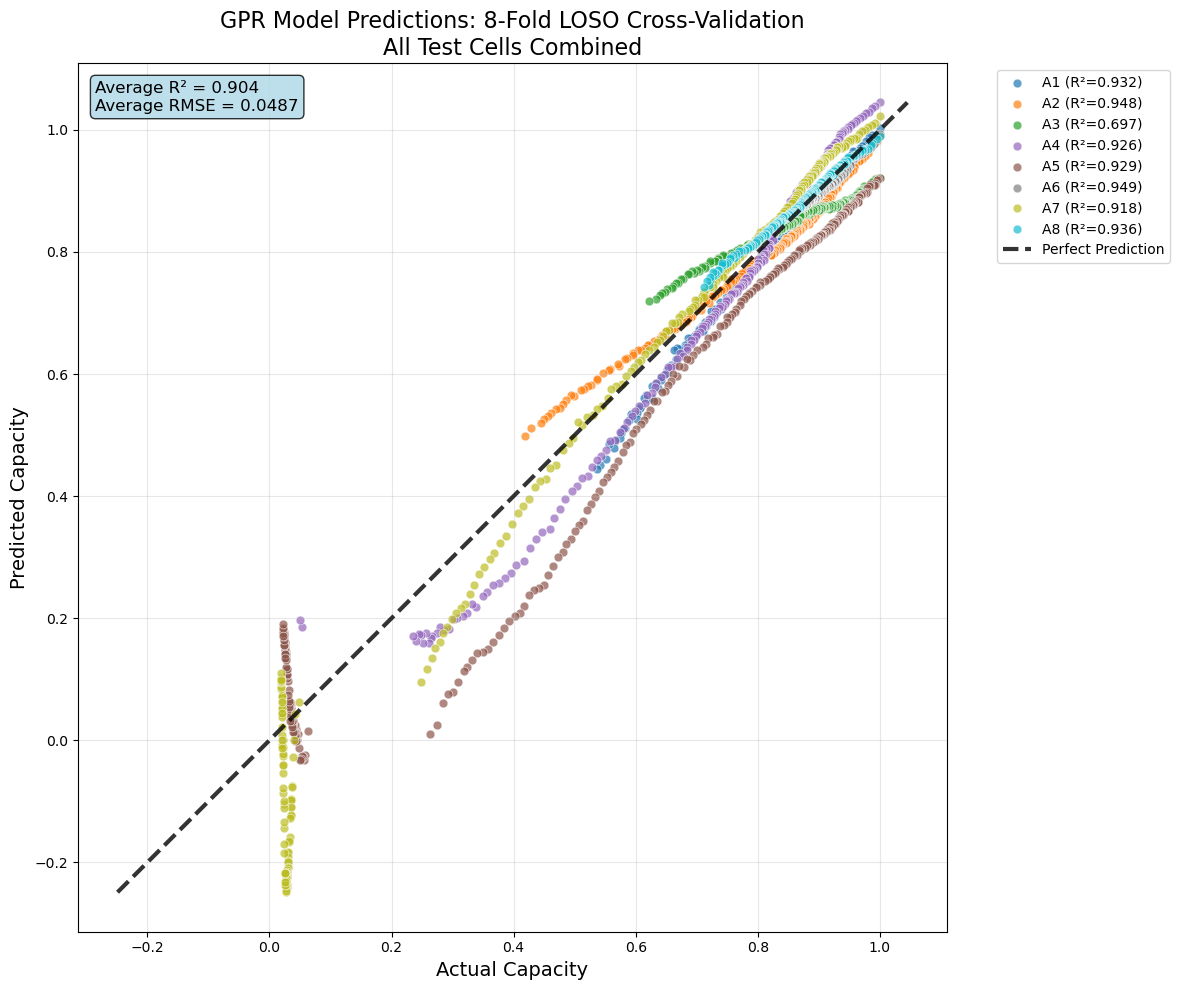

In [38]:
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

# Load all saved models and generate predictions
model_dir = Path("../models/gpr_loso")
CHANNELS = ['A1','A2','A3','A4','A5','A6','A7','A8']

# Create a single large figure
fig, ax = plt.subplots(figsize=(12, 10))

# Define colors for each cell
colors = plt.cm.tab10(np.linspace(0, 1, len(CHANNELS)))

print("🔄 Loading models and generating predictions...")

all_metrics = []
min_val, max_val = float('inf'), float('-inf')

for i, test_cell in enumerate(CHANNELS):
    print(f"📊 Processing {test_cell}...")
    
    # Load the saved model
    model_path = model_dir / f"gpr_model_{test_cell}_holdout.pkl"
    model = joblib.load(model_path)
    
    # Recreate the LOSO split for this cell
    train_cells = [c for c in CHANNELS if c != test_cell]
    df_train, df_test = loso(train_cells, [test_cell])
    
    X_train, y_train = build_model_input(df_train)
    X_test, y_test = build_model_input(df_test)
    
    # Generate predictions
    y_pred, y_std = gpr.predict_fast(model, X_test)
    
    # Calculate metrics
    rmse, r2, mse, mae = evaluate.evaluate_model(y_test, y_pred)
    all_metrics.append((test_cell, rmse, r2, mse, mae))
    
    # Update min/max for perfect prediction line
    min_val = min(min_val, y_test.min(), y_pred.min())
    max_val = max(max_val, y_test.max(), y_pred.max())
    
    # Plot with unique color for each cell (fixed: removed .iloc)
    ax.scatter(y_test, y_pred, alpha=0.7, s=40, color=colors[i], 
               label=f'{test_cell} (R²={r2:.3f})', edgecolors='white', linewidth=0.5)

# Perfect prediction line
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=3, alpha=0.8, label='Perfect Prediction')

# Labels and formatting
ax.set_xlabel('Actual Capacity', fontsize=14)
ax.set_ylabel('Predicted Capacity', fontsize=14)
ax.set_title('GPR Model Predictions: 8-Fold LOSO Cross-Validation\nAll Test Cells Combined', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Add summary statistics
avg_r2 = np.mean([r2 for _, _, r2, _, _ in all_metrics])
avg_rmse = np.mean([rmse for _, rmse, _, _, _ in all_metrics])
stats_text = f'Average R² = {avg_r2:.3f}\nAverage RMSE = {avg_rmse:.4f}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save the comprehensive plot
plot_path = Path("../results/gpr") / "gpr_all_predictions_combined.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"💾 Saved comprehensive prediction plot to: {plot_path}")

# Print summary table
print("\n📊 Summary of Results:")
print("Cell  | RMSE   | R²     | MAE    | MSE")
print("------|--------|--------|--------|--------")
for cell, rmse, r2, mse, mae in all_metrics:
    print(f"{cell:5s} | {rmse:.4f} | {r2:.3f} | {mae:.4f} | {mse:.6f}")
print(f"{'Avg':5s} | {avg_rmse:.4f} | {avg_r2:.3f}")

plt.show()